In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [4]:
cluster_satisfaction = train_df.groupby("Passenger_Segment")["satisfaction"].mean().sort_values(ascending=False)

print(cluster_satisfaction)

Passenger_Segment
Premium Loyal Travelers      0.848081
At-Risk Passengers           0.569053
Comfort-Focused Travelers    0.174635
Budget Frequent Travelers    0.149821
Name: satisfaction, dtype: float64


In [3]:
train_df = pd.read_csv("../data/train_clustered.csv")

train_df.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction,Overall_Service_Score,Comfort_Score,Digital_Experience,Total_Delay,Customer_Value,Travel_Experience,Cluster,Passenger_Segment
0,1,0,13.0,1,2,460.0,3.0,4.0,3.0,1.0,5.0,3.0,5.0,5.0,4.0,3.0,4.0,4.0,5.0,5.0,25.0,18.0,0,4.181818,4.333333,3.000000,43.0,1923.636364,3.838384,3,At-Risk Passengers
1,1,1,25.0,0,0,235.0,3.0,2.0,3.0,3.0,1.0,3.0,1.0,1.0,1.0,5.0,3.0,1.5,4.0,1.0,1.0,6.0,0,2.227273,2.333333,3.000000,7.0,523.409091,2.520202,2,Budget Frequent Travelers
2,0,0,26.0,0,0,1142.0,2.0,2.0,2.0,2.0,5.0,5.0,5.0,5.0,4.0,3.0,4.0,4.0,4.0,5.0,0.0,0.0,1,4.181818,4.333333,3.000000,0.0,4775.636364,3.838384,3,At-Risk Passengers
3,0,0,25.0,0,0,562.0,2.0,5.0,5.0,5.0,2.0,2.0,2.0,2.0,2.0,5.0,3.0,1.5,4.0,2.0,11.0,9.0,0,2.500000,3.000000,3.000000,20.0,1405.000000,2.833333,2,Budget Frequent Travelers
4,1,0,61.0,0,0,214.0,3.0,3.0,3.0,3.0,4.0,5.0,5.0,3.0,3.0,4.0,4.0,3.0,3.0,3.0,0.0,0.0,1,3.636364,4.000000,3.666667,0.0,778.181818,3.767677,3,At-Risk Passengers


In [5]:
regression_results = pd.read_csv("../reports/regression_results.csv")

classification_results = pd.read_csv("../reports/classification_results.csv")

cluster_profile = pd.read_csv("../reports/cluster_profile.csv")

In [6]:
summary = pd.DataFrame({

    "Metric":[

        "Total Passengers",

        "Features",

        "Satisfied",

        "Neutral/Dissatisfied"

    ],

    "Value":[

        len(train_df),

        train_df.shape[1],

        train_df["satisfaction"].sum(),

        len(train_df)-train_df["satisfaction"].sum()

    ]

})

summary

,Metric,Value
0,Total Passengers,103904
1,Features,31
2,Satisfied,45025
3,Neutral/Dissatisfied,58879


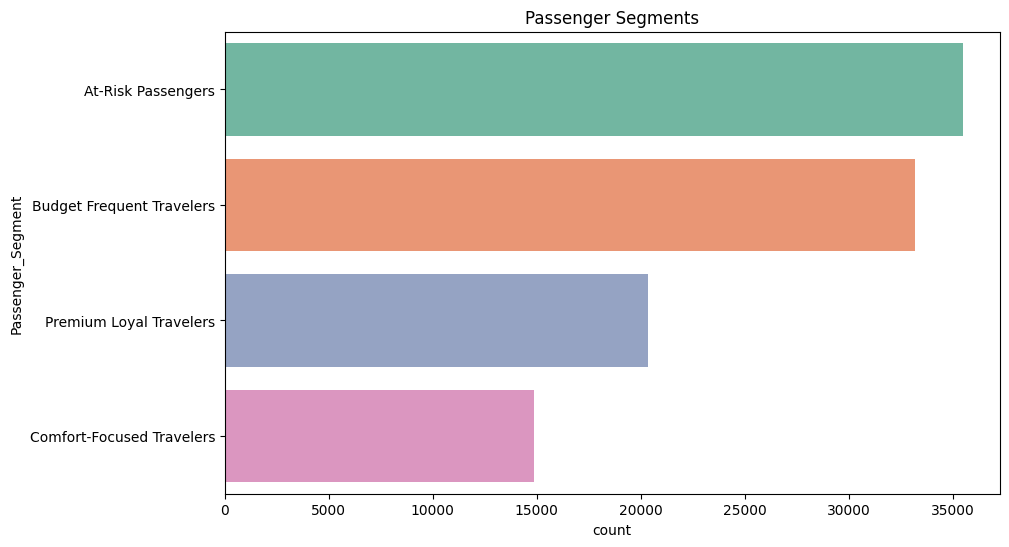

In [7]:
plt.figure(figsize=(10,6))

sns.countplot(

    data=train_df,

    y="Passenger_Segment",

    order=train_df["Passenger_Segment"].value_counts().index,

    palette="Set2"

)

plt.title("Passenger Segments")

plt.show()

In [8]:
segment_satisfaction = train_df.groupby(

    "Passenger_Segment"

)["satisfaction"].mean().sort_values(ascending=False)

segment_satisfaction

Passenger_Segment
Premium Loyal Travelers      0.848081
At-Risk Passengers           0.569053
Comfort-Focused Travelers    0.174635
Budget Frequent Travelers    0.149821
Name: satisfaction, dtype: float64

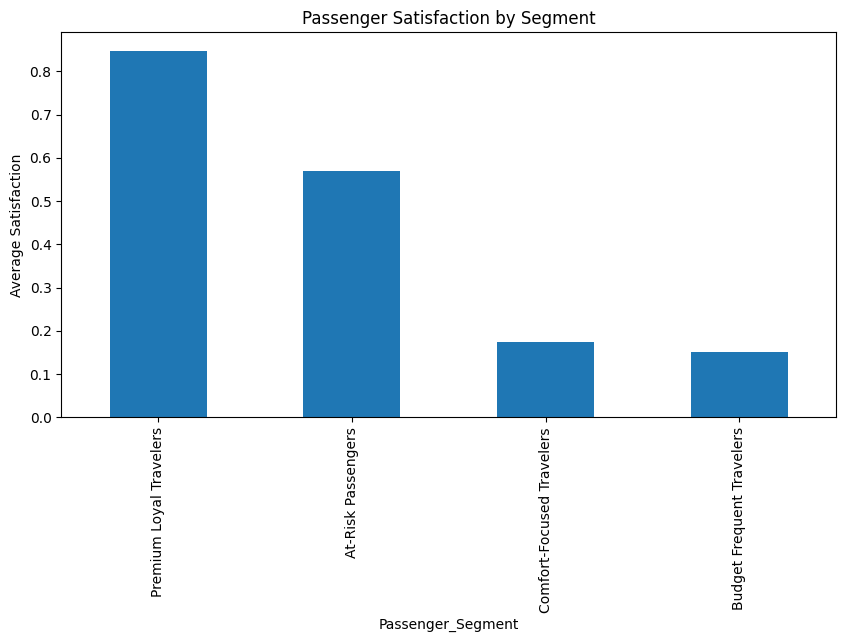

In [9]:
plt.figure(figsize=(10,5))

segment_satisfaction.plot(

    kind="bar"

)

plt.ylabel("Average Satisfaction")

plt.title("Passenger Satisfaction by Segment")

plt.show()

In [10]:
delay = train_df.groupby(

    "Passenger_Segment"

)["Total_Delay"].mean().sort_values()

delay

Passenger_Segment
Budget Frequent Travelers     5.141114
At-Risk Passengers            8.894750
Premium Loyal Travelers      13.573773
Comfort-Focused Travelers    55.663304
Name: Total_Delay, dtype: float64

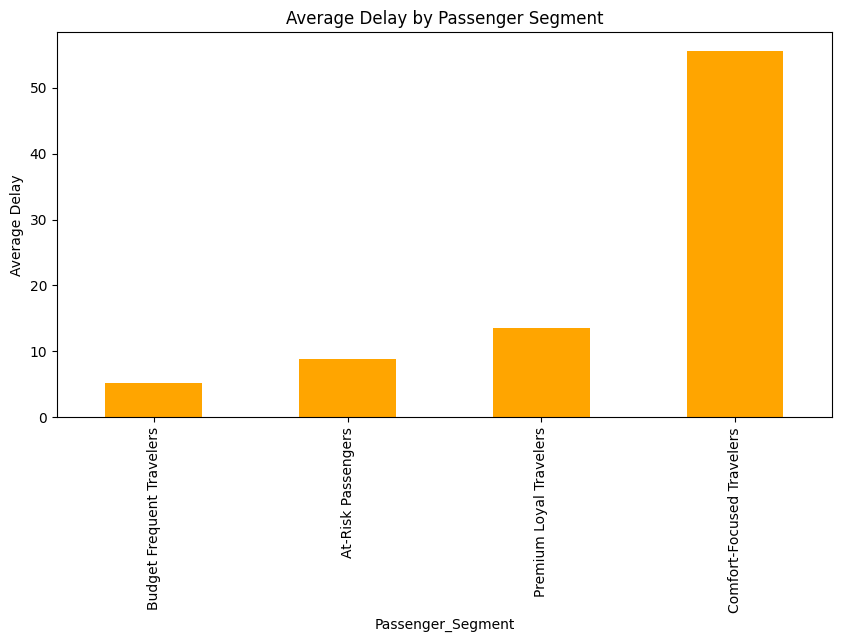

In [11]:
plt.figure(figsize=(10,5))

delay.plot(

    kind="bar",

    color="orange"

)

plt.ylabel("Average Delay")

plt.title("Average Delay by Passenger Segment")

plt.show()

In [12]:
customer_value = train_df.groupby(

    "Passenger_Segment"

)["Customer_Value"].mean().sort_values()

customer_value

Passenger_Segment
Budget Frequent Travelers     2333.423188
Comfort-Focused Travelers     2579.312611
At-Risk Passengers            2650.718171
Premium Loyal Travelers      10510.224899
Name: Customer_Value, dtype: float64

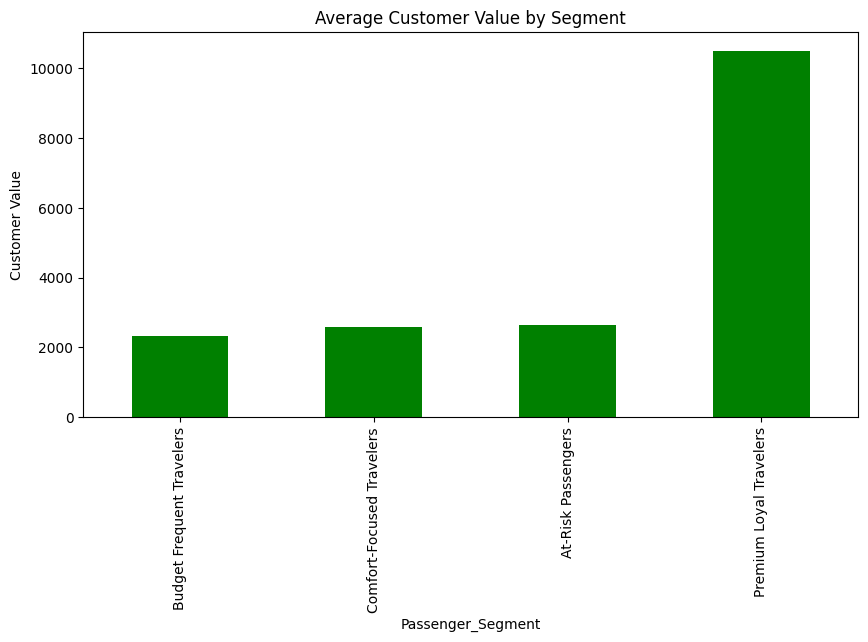

In [13]:
plt.figure(figsize=(10,5))

customer_value.plot(

    kind="bar",

    color="green"

)

plt.ylabel("Customer Value")

plt.title("Average Customer Value by Segment")

plt.show()

In [14]:
service_columns = [

    "Inflight wifi service",

    "Food and drink",

    "Online boarding",

    "Seat comfort",

    "Inflight entertainment",

    "On-board service",

    "Leg room service",

    "Baggage handling",

    "Checkin service",

    "Inflight service",

    "Cleanliness"

]

service_summary = train_df[service_columns].mean().sort_values()

service_summary

Inflight wifi service     2.729683
Food and drink            3.202129
Online boarding           3.250375
Cleanliness               3.286351
Leg room service          3.351055
Inflight entertainment    3.358158
Checkin service           3.366333
On-board service          3.382363
Seat comfort              3.439396
Baggage handling          3.631833
Inflight service          3.640428
dtype: float64

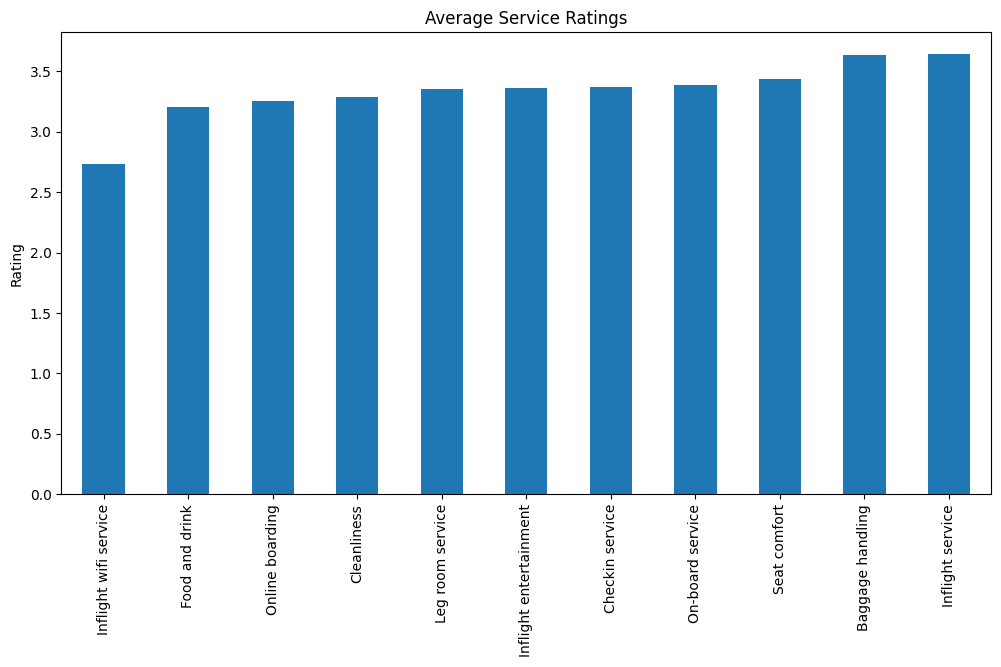

In [15]:
plt.figure(figsize=(12,6))

service_summary.plot(

    kind="bar"

)

plt.title("Average Service Ratings")

plt.ylabel("Rating")

plt.show()

In [16]:
regression_results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,503.486534,718.510383,0.963675
1,Ridge Regression,503.485458,718.510370,0.963675


In [17]:
classification_results

,Metric,Score
0,Accuracy,0.865021
1,Precision,0.864534
2,Recall,0.816435
3,F1,0.839797
4,ROC_AUC,0.920451


In [18]:
dashboard = pd.DataFrame({

    "KPI":[

        "Total Passengers",

        "Average Satisfaction",

        "Average Delay",

        "Average Customer Value"

    ],

    "Value":[

        len(train_df),

        round(train_df["satisfaction"].mean(),2),

        round(train_df["Total_Delay"].mean(),2),

        round(train_df["Customer_Value"].mean(),2)

    ]

})

dashboard

,KPI,Value
0,Total Passengers,103904.00
1,Average Satisfaction,0.43
2,Average Delay,15.31
3,Average Customer Value,4078.68


In [19]:
dashboard.to_csv(

    "../reports/executive_dashboard.csv",

    index=False

)

In [20]:
recommendations = [

    "Improve flight punctuality to reduce passenger delays.",

    "Focus on improving low-rated services such as Wi-Fi or food where applicable.",

    "Reward high-value passenger segments with loyalty benefits.",

    "Offer personalized promotions to medium-value passengers.",

    "Use the satisfaction prediction model to identify passengers needing proactive support.",

    "Monitor cluster-specific KPIs to improve customer retention."

]

recommendation_df = pd.DataFrame({

    "Recommendation":recommendations

})

recommendation_df

,Recommendation
0,Improve flight punctuality to reduce passenger...
1,Focus on improving low-rated services such as ...
2,Reward high-value passenger segments with loya...
3,Offer personalized promotions to medium-value ...
4,Use the satisfaction prediction model to ident...
5,Monitor cluster-specific KPIs to improve custo...


In [21]:
recommendation_df.to_csv(

    "../reports/business_recommendations.csv",

    index=False
)

In [22]:
executive_summary = pd.DataFrame({

    "Section":[

        "EDA",

        "Clustering",

        "Regression",

        "Classification",

        "Business"

    ],

    "Summary":[

        "Passenger demographics and service ratings were explored.",

        "Passengers were segmented into business-relevant groups.",

        "Customer Value was successfully modeled using regression.",

        "Passenger satisfaction was predicted using Logistic Regression.",

        "Insights support targeted service improvements and loyalty strategies."

    ]

})

executive_summary

,Section,Summary
0,EDA,Passenger demographics and service ratings wer...
1,Clustering,Passengers were segmented into business-releva...
2,Regression,Customer Value was successfully modeled using ...
3,Classification,Passenger satisfaction was predicted using Log...
4,Business,Insights support targeted service improvements...


In [23]:
executive_summary.to_csv(

    "../reports/executive_summary.csv",

    index=False
)

## 1. Passenger Satisfaction

* Higher overall service quality is associated with higher passenger satisfaction.
* Reduced delays correspond to improved satisfaction levels.

## 2. Passenger Segmentation

* Premium passenger segments contribute the highest customer value.
* Some segments experience lower service ratings and require targeted improvements.

## 3. Service Quality

* Identify the lowest-rated services from your `service_summary` and prioritize improvements there.
* Continue investing in the highest-rated services to maintain customer satisfaction.

## 4. Operational Improvements

* Reduce departure and arrival delays.
* Improve boarding efficiency.
* Monitor service quality across all travel classes.

## 5. Marketing Strategy

* Reward loyal passengers with exclusive benefits.
* Offer personalized promotions to medium-value customers.
* Design retention campaigns for segments with lower satisfaction.

## 6. Predictive Analytics

* Use the classification model to identify passengers at risk of dissatisfaction before future travel.
* Use regression outputs to estimate customer value and support resource allocation.
